In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
master_df = pd.read_csv("../data/master_dataset.csv")

In [3]:
master_df["order_purchase_timestamp"] = pd.to_datetime(
    master_df["order_purchase_timestamp"]
)

In [4]:
master_df["year"] = master_df["order_purchase_timestamp"].dt.year
master_df["month"] = master_df["order_purchase_timestamp"].dt.month
master_df["day"] = master_df["order_purchase_timestamp"].dt.day
master_df["day_of_week"] = master_df["order_purchase_timestamp"].dt.dayofweek

In [5]:
master_df[
    ["order_purchase_timestamp", "year", "month", "day", "day_of_week"]
].head()

,order_purchase_timestamp,year,month,day,day_of_week
0,2017-10-02 10:56:33,2017,10,2,0
1,2017-10-02 10:56:33,2017,10,2,0
2,2017-10-02 10:56:33,2017,10,2,0
3,2018-07-24 20:41:37,2018,7,24,1
4,2018-08-08 08:38:49,2018,8,8,2


In [6]:
daily_sales = (
    master_df.groupby(master_df["order_purchase_timestamp"].dt.date)
    .size()
    .reset_index(name="sales")
)

In [7]:
daily_sales.head()

,order_purchase_timestamp,sales
0,2016-09-04,2
1,2016-09-05,1
2,2016-09-13,1
3,2016-09-15,3
4,2016-10-02,1


In [8]:
daily_sales.columns = ["date", "sales"]

In [9]:
daily_sales.head()

,date,sales
0,2016-09-04,2
1,2016-09-05,1
2,2016-09-13,1
3,2016-09-15,3
4,2016-10-02,1


In [10]:
daily_sales["date"] = pd.to_datetime(daily_sales["date"])

In [11]:
daily_sales.head()

,date,sales
0,2016-09-04,2
1,2016-09-05,1
2,2016-09-13,1
3,2016-09-15,3
4,2016-10-02,1


In [12]:
daily_sales = daily_sales.sort_values("date")

In [13]:
daily_sales.head()

,date,sales
0,2016-09-04,2
1,2016-09-05,1
2,2016-09-13,1
3,2016-09-15,3
4,2016-10-02,1


In [14]:
daily_sales["lag_1"] = daily_sales["sales"].shift(1)

In [15]:
daily_sales["rolling_mean_7"] = (
    daily_sales["sales"].rolling(window=7).mean()
)

In [16]:
daily_sales.head(10)

,date,sales,lag_1,rolling_mean_7
0,2016-09-04,2,NaN,NaN
1,2016-09-05,1,2.0,NaN
2,2016-09-13,1,1.0,NaN
3,2016-09-15,3,1.0,NaN
4,2016-10-02,1,3.0,NaN
5,2016-10-03,8,1.0,NaN
6,2016-10-04,79,8.0,13.571429
7,2016-10-05,65,79.0,22.571429
8,2016-10-06,60,65.0,31.000000
9,2016-10-07,54,60.0,38.571429


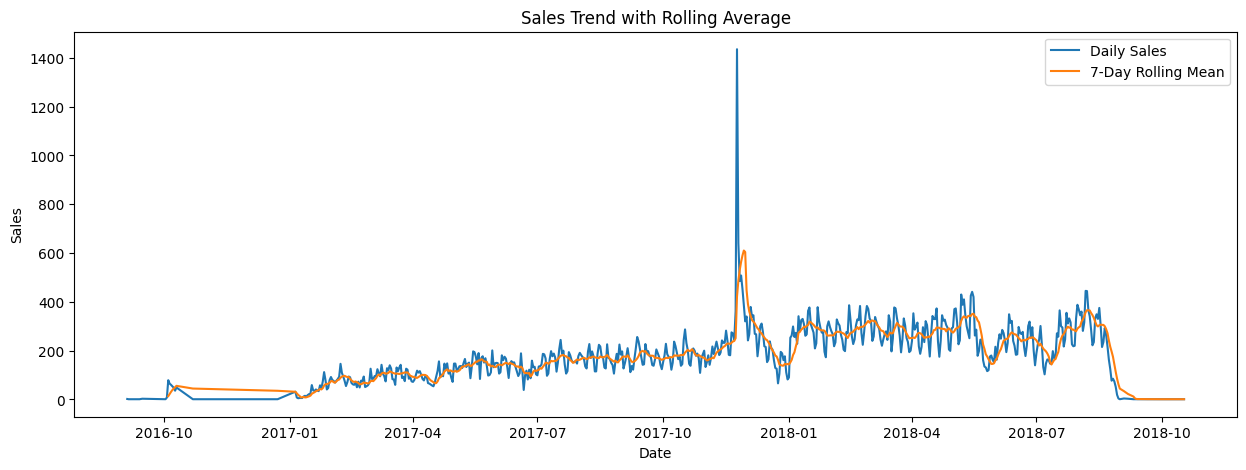

In [17]:
plt.figure(figsize=(15,5))

plt.plot(daily_sales["date"], daily_sales["sales"], label="Daily Sales")

plt.plot(
    daily_sales["date"],
    daily_sales["rolling_mean_7"],
    label="7-Day Rolling Mean"
)

plt.title("Sales Trend with Rolling Average")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.show()

In [18]:
daily_sales = daily_sales.dropna()

In [19]:
daily_sales.head()

,date,sales,lag_1,rolling_mean_7
6,2016-10-04,79,8.0,13.571429
7,2016-10-05,65,79.0,22.571429
8,2016-10-06,60,65.0,31.000000
9,2016-10-07,54,60.0,38.571429
10,2016-10-08,48,54.0,45.000000


In [20]:
features = ["lag_1", "rolling_mean_7"]

In [21]:
X = daily_sales[features]

In [22]:
y = daily_sales["sales"]

In [23]:
X.shape, y.shape

((628, 2), (628,))

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [27]:
X_train.shape, X_test.shape

((502, 2), (126, 2))